# Phase 2 on a TPU v5e — `fused_gated_mlp`

This notebook tests and benchmarks a custom Pallas `fused_gated_mlp` kernel on actual
TPU v5e hardware across four key areas: hardware correctness, VMEM memory limits,
roofline performance, and DMA copy elision.

## Core objectives and findings

### 1. Correctness on device

Goal: verify that the Pallas kernel executes accurately on TPU hardware (since standard
CPU interpret mode does not guarantee on-device correctness).

Result: at `DEFAULT` precision, the kernel uses bf16 matrix multiplication passes with
fp32 accumulation. The maximum absolute error against the CPU fp32 reference is ~0.0096
(relative error ~3.03). This error is bounded and expected for single-pass bf16
operations rather than a bug.

### 2. Precision and emulation passes

* **`DEFAULT` precision:** performs 1 bf16 pass per operation (~197 TFLOP/s peak).
* **`HIGHEST` precision:** performs 6 bf16 passes to emulate full-mantissa precision,
  dropping absolute error to ~2.05e-5 (approaching the CPU reference noise floor).
* **`HIGH` precision limitations:** in JAX 0.11.0, the Mosaic lowering rule for
  `dot_general` does not support `HIGH` precision (3-pass bf16), raising a
  `NotImplementedError`. Thus, testing focuses on `DEFAULT` vs. `HIGHEST`.

### 3. VMEM budget discovery

Limit: the default scoped VMEM limit (`--xla_tpu_scoped_vmem_limit_kib`) allocated to a
`pallas_call` on TPU v5e is 16 MiB, even though the physical hardware capacity is
128 MiB.

Workaround: kernel configurations exceeding 16 MiB (such as larger block sizes like
`block_h=768`) can be compiled by passing explicit memory parameters via
`pltpu.CompilerParams(vmem_limit_bytes=...)`.

### 4. Memory bandwidth and DMA copy elision

Weight access pattern: with grid ordering iterating through hidden blocks, weight
tensors are re-read once per token step (`t`).

Copy elision verification: memory counts and DMA trace profiling confirm how weight
slices are transferred and whether consecutive identical weight fetches are omitted
during execution.

## 0 · Preflight

Refuses to go on without a TPU, and prints the hardware constants everything
below is measured against. `tpu_info` is the only primary source found that
states v5e VMEM; `docs.cloud.google.com/tpu/docs/v5e` does not.

In [1]:
# The Colab TPU runtime ships jax 0.7.2, which has no
# jax._src.pallas.mosaic.tpu_info. Upgrade, then restart the session.
%pip install -q -U "jax[tpu]>=0.11.0"

import jax

# The upgrade lands on disk but not in a kernel that already imported jax, so
# say so plainly rather than failing on the tpu_info import three lines down.
# Compared as integers: "0.7.2" sorts *after* "0.11.0" as a string.
installed = tuple(int(part) for part in jax.__version__.split(".")[:2])
assert installed >= (0, 11), (
    f"jax is still {jax.__version__} in this kernel. Runtime > Restart session, "
    "then re-run this cell. The pip line above only takes effect after a restart."
)

from jax._src.pallas.mosaic import tpu_info as ti

print("jax        ", jax.__version__)
print("devices    ", jax.devices())

platform = jax.devices()[0].platform
assert platform == "tpu", (
    f"backend is {platform!r}, not tpu. Runtime > Change runtime type > TPU. "
    "No number produced here would be publishable."
)

# The first argument must be the ChipVersion enum member; a string fails late
# and unhelpfully on `.is_lite`. Second argument is TensorCores per device.
info = ti.get_tpu_info_for_chip(ti.ChipVersion.TPU_V5E, 1)
for field in (
    "bf16_ops_per_second",
    "mem_bw_bytes_per_second",
    "vmem_capacity_bytes",
    "smem_capacity_bytes",
    "hbm_capacity_bytes",
    "num_mxus",
    "mxu_column_size",
    "num_lanes",
    "num_sublanes",
):
    print(f"{field:26} {getattr(info, field):>20,}")

print()
print(f"VMEM {info.vmem_capacity_bytes / 1024**2:.0f} MiB is the *physical* capacity.")
print("What a pallas_call is allowed to use is the scoped-vmem limit -- cell 4.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 88.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.66.0 requires numpy<2.5,>=1.22, but you have numpy 2.5.2 which is incompatible.


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


jax         0.11.0
devices     [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
bf16_ops_per_second         197,000,000,000,000
mem_bw_bytes_per_second         820,000,000,000
vmem_capacity_bytes                 134,217,728
smem_capacity_bytes                   1,048,576
hbm_capacity_bytes               17,200,000,000
num_mxus                                      4
mxu_column_size                             128
num_lanes                                   128
num_sublanes                                  8

VMEM 128 MiB is the *physical* capacity.
What a pallas_call is allowed to use is the scoped-vmem limit -- cell 4.


## 1 · Setup

Clone and install the package only — `--no-deps`.

Every section below writes to `/content`, which dies with the runtime.

In Google Colab, `/content` is the root working directory on temporary virtual
machines. Any files created or modified here exist in ephemeral storage. Once your
TPU runtime resets, disconnects, or times out, the environment is deleted along with
all files stored under `/content`.

Section 8 of the notebook bundles all those saved result files into a single `.zip`
file, and downloads them to your local computer.

In [2]:
import pathlib
import sys

RESULTS = pathlib.Path("/content/results")
TRACES = pathlib.Path("/content/traces")
for directory in (RESULTS, TRACES):
    directory.mkdir(parents=True, exist_ok=True)

REPO = pathlib.Path("/content/gemma3-tpu-pallas")
if not REPO.exists():
    !git clone --depth 1 https://github.com/denis-mil/gemma3-tpu-pallas {REPO}

%pip install -q -e {REPO} --no-deps

# Belt and braces: makes the cell re-runnable without a kernel restart if the
# editable install has not yet landed on sys.path.
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

import gemma3_pallas

print("package at ", gemma3_pallas.__file__)
print("artifacts at", RESULTS)

# Artifacts left by an earlier run of this session. A re-run overwrites the file
# it produces, so anything worth keeping should be downloaded first.
existing = sorted(path for path in RESULTS.rglob("*") if path.is_file())
if existing:
    print(f"\n{len(existing)} artifact(s) already present:")
    for path in existing:
        print(f"  {path.relative_to(RESULTS)}  {path.stat().st_size / 1e3:.0f} kB")

Cloning into '/content/gemma3-tpu-pallas'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 183 (delta 0), reused 151 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 297.82 KiB | 9.31 MiB/s, done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gemma3-pallas (pyproject.toml) ... done
package at  /content/gemma3-tpu-pallas/src/gemma3_pallas/__init__.py
artifacts at /content/results


## 2 · Correctness on device

Validates that the Pallas `fused_gated_mlp` kernel produces accurate mathematical
results when executing directly on physical TPU v5e hardware, rather than just
simulating execution in CPU interpret mode.

In [3]:
import json

import numpy as np
import jax.numpy as jnp

from gemma3_pallas import bench
from gemma3_pallas.mlp import fused_gated_mlp
from gemma3_pallas.reference import gated_mlp
from gemma3_pallas.shapes import GEMMA3_1B

bench.require_tpu()

# block_h = 384, not 768. At 768 the five double-buffered blocks come to
# 22.50 MiB and Mosaic refuses the kernel at the default scoped-VMEM limit:
#
#   Scoped allocation with size 22.50M and limit 16.00M exceeded scoped vmem
#   limit by 6.50M
#
# That message is cell 4's answer arriving early -- the undocumented default of
# --xla_tpu_scoped_vmem_limit_kib is 16 MiB -- and it is recorded as such rather
# than worked around silently. It also disagrees with the working-set model in
# cell 4: the two [block_t, block_h] intermediates (0.75 MiB at 128x768) are not
# in the 22.50 MiB the compiler counted, so they are not part of the same
# allocation. Correctness needs no particular block size, so this cell takes the
# largest geometry that fits (12.75 MiB by that model) and cell 4 measures the
# boundary properly.
TOKENS, BLOCK_T, BLOCK_H = 256, 128, 384

x, w_gate, w_up, w_down = bench.operands(TOKENS)
# Ground truth must not share the kernel's rounding. Jitted with no placement,
# `gated_mlp` runs on the TPU, where its bare `@` lowers at DEFAULT precision --
# bf16 multiplies. A bf16 kernel would then "agree" with it to fp32 accumulation
# noise (~1e-6) while both sat ~1e-2 from the true answer, and the agreement
# would read as accuracy. Committing the operands to the CPU puts the reference
# on a backend where fp32 multiplies are fp32, at the cost of a few seconds.
CPU = jax.devices("cpu")[0]
reference_out = np.asarray(
    jax.jit(gated_mlp)(*(jax.device_put(a, CPU) for a in (x, w_gate, w_up, w_down)))
)
scale = float(np.abs(reference_out).max())


def error_report(precision, *, block_t=BLOCK_T, block_h=BLOCK_H, vmem_limit_bytes=None):
    """Max absolute and relative error against the fp32 reference, on device.

    `vmem_limit_bytes` raises the scoped-VMEM budget for this one call, so a
    geometry that will not compile at the default can still be checked for
    correctness -- pass e.g. 64 * 1024**2 with block_h=768.
    """
    from jax.experimental.pallas import tpu as pltpu

    compiler_params = (
        None
        if vmem_limit_bytes is None
        else pltpu.CompilerParams(vmem_limit_bytes=vmem_limit_bytes)
    )
    got = np.asarray(
        fused_gated_mlp(
            x,
            w_gate,
            w_up,
            w_down,
            block_t=block_t,
            block_h=block_h,
            interpret=False,
            precision=precision,
            compiler_params=compiler_params,
        )
    )
    absolute = np.abs(got - reference_out)
    # Guarded: the output has near-zero entries, and a relative error against
    # one of those says more about the divisor than about the kernel.
    denominator = np.maximum(np.abs(reference_out), 1e-3 * scale)
    return {
        "precision": bench.precision_label(precision),
        "tokens": TOKENS,
        "block_t": block_t,
        "block_h": block_h,
        "vmem_limit_bytes": vmem_limit_bytes,
        "output_scale": scale,
        "max_abs_error": float(absolute.max()),
        "max_rel_error": float((absolute / denominator).max()),
        "cpu_reference_max_abs_error": 3.28e-6,
    }


correctness = [error_report(None)]
(RESULTS / "correctness.json").write_text(json.dumps(correctness, indent=2))

row = correctness[0]
print(f"block_t={row['block_t']}, block_h={row['block_h']}")
print(f"output scale        {row['output_scale']:.4g}")
print(f"max abs error       {row['max_abs_error']:.4g}   (CPU interpret run: 3.28e-6)")
print(f"max rel error       {row['max_rel_error']:.4g}")
print()
print("Nonzero but bounded is the expected shape of this result. A max abs error")
print("of ~1e-2 at DEFAULT is bf16 multiplies, not a bug; 0.0 would be the")
print("surprise, and a NaN or a value comparable to the output scale is a bug.")

block_t=128, block_h=384
output scale        2.152
max abs error       0.009636   (CPU interpret run: 3.28e-6)
max rel error       3.034

Nonzero but bounded is the expected shape of this result. A max abs error
of ~1e-2 at DEFAULT is bf16 multiplies, not a bug; 0.0 would be the
surprise, and a NaN or a value comparable to the output scale is a bug.


## 3 · Precision probe

Evaluates how numerical precision settings (`DEFAULT` vs. `HIGHEST`) affect error
rates and theoretical performance roofs in Mosaic/Pallas TPU kernels, while
documenting current JAX toolchain limitations.

### Core concept and purpose

TPU v5e hardware does not have a native, single-pass hardware unit for 32-bit
floating-point (fp32) matrix multiplication. Instead, higher-precision matmuls are
emulated by executing multiple 16-bit bfloat16 (bf16) passes.

The precision probe establishes empirical evidence for how many passes each
precision mode performs, determining the theoretical peak performance (roofline)
used for benchmark comparisons later in the notebook:

**`DEFAULT` precision**

- Passes: 1 bf16 pass per operation (with fp32 accumulation).
- Peak compute: ~197 TFLOP/s.
- Accuracy: yields an absolute error around ~1e-2 (~0.0096) against an fp32 CPU
  reference, which is the expected noise floor for single-pass bf16.

**`HIGHEST` precision**

- Passes: 6 bf16 passes to emulate full-mantissa precision.
- Peak compute: 197 TFLOP/s / 6 ≈ 32.8 TFLOP/s.
- Accuracy: error drops monotonically to ~2.05e-5, approaching the CPU baseline
  noise floor (3.28e-6).

### Why `HIGH` is not probed

Mosaic's `dot_general` lowering rule on jax 0.11.0 accepts `DEFAULT` and `HIGHEST`
only; anything else lands in the `else` and raises:

```
NotImplementedError: Unsupported dot precision: HIGH
  jax/_src/pallas/mosaic/lowering.py:2879, in _dot_general_lowering_rule
```

The `bf16x3` branch that would accept it —

```python
elif precision == lax.Precision.HIGH:
    precision_attr = ir.Attribute.parse("#tpu.contract_precision<bf16x3>")
```

— exists on `jax` `main` and in no release: 0.11.0 is the newest on PyPI, and the
tagged `jax-v0.11.0` file raises at exactly the line in the traceback. The XLA
path is unaffected, because `jax.default_matmul_precision` reaches XLA rather than
Mosaic, but a kernel row and an XLA row are only comparable at the same precision,
so every sweep below drops `HIGH` on both.

So this cell asks `DEFAULT` versus `HIGHEST` — 1 pass versus 6 — and the 3-pass
roof stays a prediction that *could not be tested on this runtime*, rather than
one that failed. The probe is written so an unlowerable precision is *recorded*,
with the compiler's message, rather than killing the cell: same treatment cell 4
gives a Mosaic VMEM failure.

In [4]:
# "high" is absent: Mosaic on jax 0.11.0 has no lowering branch for it and
# raises at trace time. It is left in the list below, commented, so the omission
# reads as a toolchain limit rather than an oversight -- and so it can be put
# back on a jax that carries the #tpu.contract_precision<bf16x3> branch.
PROBE_PRECISIONS = ("highest",)  # ("high", "highest") once HIGH lowers


def probe(precision):
    """`error_report`, but a precision Mosaic cannot lower is a recorded result.

    A lowering refusal is a fact about the toolchain and belongs in the
    artifact; it should also not cost the rows that do lower, which is why this
    catches rather than letting the cell die.
    """
    try:
        return error_report(precision)
    except NotImplementedError as exc:
        return {
            "precision": bench.precision_label(precision),
            "tokens": TOKENS,
            "block_t": BLOCK_T,
            "block_h": BLOCK_H,
            "status": "unsupported",
            "error": str(exc),
            "jax_version": jax.__version__,
        }


for precision in PROBE_PRECISIONS:
    correctness.append(probe(precision))

(RESULTS / "correctness.json").write_text(json.dumps(correctness, indent=2))

print(f"{'precision':<10} {'max abs':>12} {'max rel':>12}   vs CPU 3.28e-6")
for row in correctness:
    if row.get("status") == "unsupported":
        print(f"{row['precision']:<10} {'not lowerable':>12}   {row['error'].splitlines()[0]}")
        continue
    ratio = row["max_abs_error"] / 3.28e-6
    print(
        f"{row['precision']:<10} {row['max_abs_error']:>12.4g} "
        f"{row['max_rel_error']:>12.4g}   {ratio:>10.1f}x"
    )

print()
print("Read this as: whichever precision lands near the fp32 noise floor of the")
print("CPU reference (3.28e-6) is the one doing full-mantissa work, and its pass")
print("count is the divisor on the 197 TFLOP/s roof. DEFAULT should sit ~1e-2 --")
print("one bf16 pass -- and HIGHEST near the floor at six, which is the pass count")
print("sections 5b and 7 already score each precision's rows at. Nothing below")
print("needs setting from this table; the table is what makes those roofs")
print("defensible. A DEFAULT row far off 1e-2, or a HIGHEST row far off the")
print("floor, would mean the wrong roof is being drawn. The 3-pass roof is")
print("unreachable on this jax, so no row is scored against it.")

precision       max abs      max rel   vs CPU 3.28e-6
DEFAULT        0.009636        3.034       2937.7x
HIGHEST        2.05e-05     0.006683          6.3x

Read this as: whichever precision lands near the fp32 noise floor of the
CPU reference (3.28e-6) is the one doing full-mantissa work, and its pass
count is the divisor on the 197 TFLOP/s roof. DEFAULT should sit ~1e-2 --
one bf16 pass -- and HIGHEST near the floor at six, which is the pass count
sections 5b and 7 already score each precision's rows at. Nothing below
needs setting from this table; the table is what makes those roofs
defensible. A DEFAULT row far off 1e-2, or a HIGHEST row far off the
floor, would mean the wrong roof is being drawn. The 3-pass roof is
unreachable on this jax, so no row is scored against it.


## 4 · VMEM sweep — the budget a `pallas_call` actually gets

Empirically measures the default scoped VMEM limit imposed on Pallas kernels by
Mosaic/XLA on TPU v5e, demonstrating that a `pallas_call` is capped at a 16 MiB
default budget despite the physical chip having 128 MiB of VMEM.

### Core concept and purpose

While a TPU v5e chip possesses 128 MiB of physical Vector Memory (VMEM),
XLA/Mosaic enforces a strict default allocation limit
(`--xla_tpu_scoped_vmem_limit_kib`) for individual `pallas_call` kernel
instances — defaulting to 16 MiB.

Because JAX CPU interpretation mode (`pltpu.InterpretParams`) does not enforce
VMEM limits, on-device execution is the only way to measure this hardware
boundary. This section systematically identifies the threshold on physical
hardware by sweeping tile/block geometries (`block_t`, `block_h`) with increasing
memory requirements.

### Technical methodology and findings

**Memory allocation model (`scoped_bytes`).** When double-buffering is enabled,
Pallas prefetches block transfers across grid iterations. The compiler tracks
scoped VMEM allocation across kernel operands ($X$, $W_{gate}$, $W_{up}$,
$W_{down}$, and $Y_{out}$):

- *Double buffering rule* (`buffers_for`): an operand is allocated 2 buffers if
  its grid axis loops across multiple steps (`steps > 1`). If a grid axis
  consists of a single step (`steps == 1`), no prefetching occurs, so Mosaic
  allocates only 1 buffer. This is what allows full-width tiles (e.g.
  `block_h = 6912`) to fit inside the physical memory.
- *Intermediate tensors excluded*: the two intermediate `[block_t, block_h]`
  fp32 buffers held within the kernel body are not counted toward this
  compiler-scoped allocation check.

**Sweeping and failure bracketing.** The cell orders grid configurations
(`BLOCK_HS` × `BLOCK_TS`) by total required scoped memory.

Distinction of error types:

- `rejected` (`ValueError`): invalid tile shapes (e.g. non-divisors of the total
  dimensions, or non-multiples of the 128-lane width) fail shape validation
  rather than VMEM allocation.
- `oom` (compilation failure): configs that pass shape validation but exceed the
  default VMEM budget fail at compile time.

By capturing the largest configuration that compiles alongside the smallest
configuration that fails for memory reasons, the sweep brackets the default
16 MiB limit.


In [5]:
cfg = GEMMA3_1B


def buffers_for(steps):
    """Pallas double-buffers an operand only when its block index moves.

    A grid axis with a single step hands every visit the same block, so there is
    nothing to prefetch and Mosaic allocates one buffer instead of two. Measured:
    block_h=6912 leaves the h axis one step long and the kernel compiles inside
    128 MiB, which two 91.12 MiB weight buffers could not have.
    """
    return 2 if steps > 1 else 1


def scoped_bytes(tokens, block_t, block_h, *, cfg=cfg, dtype_bytes=4):
    """VMEM the compiler counts against `--xla_tpu_scoped_vmem_limit_kib`.

    Five blocked operands -- x, w_gate, w_up, w_down and the output -- each
    buffered according to whether its own grid axis actually loops. The two
    [block_t, block_h] intermediates are excluded: at 128x768 Mosaic reported
    22.50M against a 23.25 MiB working set, and 0.75 MiB is those two exactly.
    """
    weights = 3 * cfg.embed_dim * block_h  # w_gate, w_up, w_down
    streamed = 2 * block_t * cfg.embed_dim  # x, output
    return dtype_bytes * (
        buffers_for(cfg.hidden_dim // block_h) * weights
        + buffers_for(tokens // block_t) * streamed
    )


def working_set_bytes(tokens, block_t, block_h, *, cfg=cfg, dtype_bytes=4):
    """`scoped_bytes` plus the two fp32 intermediates the kernel body holds."""
    scoped = scoped_bytes(tokens, block_t, block_h, cfg=cfg, dtype_bytes=dtype_bytes)
    return scoped + dtype_bytes * 2 * block_t * block_h


# `_validate` requires block_h to divide hidden_dim (6912) and to be a multiple
# of the 128-lane width, so 512 and 1728 are not candidates at all: 6912 % 512
# is 256, and 1728 % 128 is 64. Such a rejection is a shape error, not a VMEM
# measurement, and the two are kept apart below. What survives has nothing
# between 384 and 768, so no choice of block narrows the bracket around the
# 16 MiB limit -- the compiler's own message is what names it.
BLOCK_HS = [128, 256, 384, 768, 1152, 2304, 3456, 6912]
BLOCK_TS = [128, 256]

vmem_specs = [
    dict(tokens=TOKENS, block_t=bt, block_h=bh, precision=None)
    for bt in BLOCK_TS
    for bh in BLOCK_HS
]
vmem_specs.sort(key=lambda s: scoped_bytes(s["tokens"], s["block_t"], s["block_h"]))

vmem_results = []
vmem_path = RESULTS / "vmem_sweep.json"


def failure_kind(result):
    """One of "ok", "rejected" (bad shape) or "oom" (the budget refused it)."""
    if result.status == "ok":
        return "ok"
    return "rejected" if result.error.startswith("ValueError") else "oom"


def keep_vmem(result):
    vmem_results.append(result)
    bench.save(vmem_results, vmem_path)  # rewritten in full after every config
    mib = scoped_bytes(result.tokens, result.block_t, result.block_h) / 1024**2
    median = result.median()
    timing = f"{1e3 * median:8.3f} ms" if median else "        --"
    print(f"block_t={result.block_t:<4} block_h={result.block_h:<5} "
          f"scoped {mib:7.2f} MiB  {failure_kind(result):<9} {timing}")


bench.sweep(vmem_specs, interpret=False, on_result=keep_vmem)


def asked(result):
    """Scoped VMEM this configuration asked for, as the sort key for extremes."""
    return scoped_bytes(result.tokens, result.block_t, result.block_h)


ok = [r for r in vmem_results if r.status == "ok"]
oom = [r for r in vmem_results if failure_kind(r) == "oom"]

print()
if ok:
    largest = max(ok, key=asked)
    print(f"largest that compiled:  {asked(largest) / 1024**2:.2f} MiB "
          f"(block_t={largest.block_t}, block_h={largest.block_h})")
if oom:
    smallest = min(oom, key=asked)
    print(f"smallest that failed:   {asked(smallest) / 1024**2:.2f} MiB "
          f"(block_t={smallest.block_t}, block_h={smallest.block_h})")
    print()
    print("first failure, verbatim:")
    print(smallest.error[:800])
else:
    print("Nothing ran out of VMEM: the sweep did not reach the budget. The bound")
    print("is only that the default exceeds the largest working set above -- say")
    print("that, rather than reporting the largest config as the limit.")


block_t=128  block_h=128   scoped    5.62 MiB  ok           0.518 ms
block_t=256  block_h=128   scoped    5.62 MiB  ok           0.366 ms
block_t=128  block_h=256   scoped    9.00 MiB  ok           0.502 ms
block_t=256  block_h=256   scoped    9.00 MiB  ok           0.352 ms
block_t=128  block_h=384   scoped   12.38 MiB  ok           0.498 ms
block_t=256  block_h=384   scoped   12.38 MiB  ok           0.372 ms
block_t=128  block_h=768   scoped   22.50 MiB  oom               --
block_t=256  block_h=768   scoped   22.50 MiB  oom               --
block_t=128  block_h=1152  scoped   32.62 MiB  oom               --
block_t=256  block_h=1152  scoped   32.62 MiB  oom               --
block_t=128  block_h=2304  scoped   63.00 MiB  oom               --
block_t=256  block_h=2304  scoped   63.00 MiB  oom               --
block_t=128  block_h=3456  scoped   93.38 MiB  oom               --
block_t=128  block_h=6912  scoped   93.38 MiB  oom               --
block_t=256  block_h=3456  scoped   93.38 

### 4b · Does `vmem_limit_bytes` move the boundary?

Verifies that passing `vmem_limit_bytes` via `pltpu.CompilerParams` overrides XLA's
default 16 MiB scoped VMEM cap, letting large kernel tile sizes compile and execute
on TPU v5e hardware.

### Core concept and purpose

In section 4, Pallas kernels with larger block sizes fail compilation because
XLA/Mosaic enforces a default 16 MiB scoped VMEM budget, despite the physical TPU v5e chip having
128 MiB of VMEM.

Section 4b tests whether explicitly setting the compiler parameter
`vmem_limit_bytes` overrides that default.

### Key technical takeaways

**The mechanism.** Passing `pltpu.CompilerParams(vmem_limit_bytes=...)` to
`fused_gated_mlp` instructs the Mosaic compiler to raise the maximum allowable VMEM
budget for that specific kernel invocation.

**Double proof.**

- *Confirms the flag works*: proves the compilation failure in section 4 came from a
  software-enforced budget cap rather than a physical hardware limit or bad memory
  indexing.
- *Validates the cap*: demonstrates that configurations requiring up to 64 MiB or
  128 MiB execute safely on the device once the compiler is given permission to
  allocate beyond the default 16 MiB boundary.


In [6]:
MiB = 1024**2
LIMITS = [16 * MiB, 32 * MiB, 64 * MiB, 100 * MiB, 128 * MiB]

if oom:
    first_refused = min(oom, key=asked)
    probe_t, probe_h = first_refused.block_t, first_refused.block_h
    print(f"probing the first config the budget refused: block_t={probe_t}, "
          f"block_h={probe_h}, "
          f"{scoped_bytes(TOKENS, probe_t, probe_h) / MiB:.2f} MiB scoped")
else:
    probe_t, probe_h = BLOCK_T, BLOCK_H
    print(f"nothing ran out of VMEM at the default; walking the limit down on the "
          f"headline geometry: block_t={probe_t}, block_h={probe_h}, "
          f"{scoped_bytes(TOKENS, probe_t, probe_h) / MiB:.2f} MiB scoped")
print()


def limit_ladder(block_t, block_h):
    return [
        dict(tokens=TOKENS, block_t=block_t, block_h=block_h, precision=None,
             vmem_limit_bytes=limit)
        for limit in LIMITS
    ]


def keep_limit(result):
    vmem_results.append(result)
    bench.save(vmem_results, vmem_path)
    median = result.median()
    timing = f"{1e3 * median:8.3f} ms" if median else "        --"
    print(f"vmem_limit={result.vmem_limit_bytes / MiB:6.0f} MiB  "
          f"{failure_kind(result):<9} {timing}")


bench.sweep(limit_ladder(probe_t, probe_h), interpret=False, on_result=keep_limit)

# The single-buffer rule makes a claim sharp enough to be wrong. block_h=6912
# leaves the h axis one step long, so the 91.12 MiB of weights is allocated once
# rather than twice and the kernel asks 93.38 MiB -- more than a 64 MiB limit
# allows, less than a 100 MiB one. A flat "everything is double buffered" model
# puts the same geometry at 184.50 MiB, which fits nowhere on a 128 MiB chip and
# would have predicted a failure this ladder is about to contradict.
FULL_H = BLOCK_HS[-1]
print()
print(f"single-buffer test: block_t=128, block_h={FULL_H} asks "
      f"{scoped_bytes(TOKENS, 128, FULL_H) / MiB:.2f} MiB scoped, against "
      f"{info.vmem_capacity_bytes / MiB:.0f} MiB on the chip. Expect ok at 100 "
      f"and 128, refused below.")
print()
bench.sweep(limit_ladder(128, FULL_H), interpret=False, on_result=keep_limit)


probing the first config the budget refused: block_t=128, block_h=768, 22.50 MiB scoped

vmem_limit=    16 MiB  oom               --
vmem_limit=    32 MiB  ok           0.487 ms
vmem_limit=    64 MiB  ok           0.488 ms
vmem_limit=   100 MiB  ok           0.503 ms
vmem_limit=   128 MiB  ok           0.497 ms

single-buffer test: block_t=128, block_h=6912 asks 93.38 MiB scoped, against 128 MiB on the chip. Expect ok at 100 and 128, refused below.

vmem_limit=    16 MiB  oom               --
vmem_limit=    32 MiB  oom               --
vmem_limit=    64 MiB  oom               --
vmem_limit=   100 MiB  ok           0.416 ms
vmem_limit=   128 MiB  ok           0.425 ms


[BenchResult(label='kernel', tokens=256, block_t=128, block_h=6912, precision='DEFAULT', vmem_limit_bytes=16777216, status='failed', times_s=(), error='JaxRuntimeError: RESOURCE_EXHAUSTED: E1001: CompileTimeScopedVmemOom:\nRan out of memory in memory space vmem while allocating on stack for %run.1 = f32[256,1152]{1,0:T(8,128)} custom-call(%x_ref.1, %wg_ref.1, %wu_ref.1, %wd_ref.1), custom_call_target="tpu_custom_call", operand_layout_constraints={f32[256,1152]{1,0}, f32[1152,6912]{1,0}, f32[1152,6912]{1,0}, f32[6912,1152]{1,0}}, frontend_attributes={kernel_metadata={}}, metadata={op_name="jit(run)/pallas_call" stack_frame_id=24}. Scoped allocation with size 93.38M and limit 16.00M exceeded scoped vmem limit by 77.38M. It should not be possible to run out of scoped vmem - \nSee https://openxla.org/xla/errors/error_1001 for more details.'),
 BenchResult(label='kernel', tokens=256, block_t=128, block_h=6912, precision='DEFAULT', vmem_limit_bytes=33554432, status='failed', times_s=(), erro

## 5 · Token sweep — the roofline points

Benchmarks kernel performance across sequence lengths
($T \in \{128, 256, 512, 1024, 2048\}$) with the block sizes held fixed
(`BEST_BLOCK_T = 128`, `BEST_BLOCK_H = 384`), deliberately isolating the memory
bandwidth penalty of re-reading the weights as the sequence grows.

### Core concept and objectives

Section 5 evaluates execution time across token counts $T$ against the
theoretical hardware limits (roofline points) on TPU v5e:

**Weight streaming cost.** `block_t` is fixed at `BEST_BLOCK_T`. The kernel processes sequence blocks sequentially, so it
re-reads the full 95.6 MB weight set at every $t$ step. At $T = 2048$ that moves
up to 1.53 GB for a problem whose unique data is only 114 MB.

**Isolating overhead.** Holding the block sizes fixed across the sweep isolates
the memory bandwidth overhead introduced by streaming the weights several times.

**Precision sweep.** The benchmark runs at the two supported precision modes —
`DEFAULT` (1 bf16 pass) and `HIGHEST` (6 bf16 passes) — to compare measured
throughput against each mode's theoretical compute roof.

**XLA baseline.** Every $T$ and precision is measured twice: once for the Pallas
kernel and once for `jax.jit(reference.gated_mlp)`, so each roofline point comes
with the compiler's own time for the same problem.

### Measurement protocol

Warmup 3, repeats 20, `block_until_ready` on every call, and the whole
distribution kept rather than a mean: a bimodal set of samples is a fact about
the run.

In [7]:
BEST_BLOCK_T = BLOCK_T
BEST_BLOCK_H = BLOCK_H

TOKEN_SWEEP = [128, 256, 512, 1024, 2048]

# DEFAULT and HIGHEST: 1 bf16 pass and 6. HIGH -- the 3-pass roof, and the one
# crossover this sweep could have resolved -- is not lowerable by Mosaic on jax
# 0.11.0 (cell 3). `bench.sweep` would record those rows as status="failed"
# rather than raise, but a column of known failures is not a measurement, so
# they are not run. HIGHEST is swept in its place: it costs nothing extra to
# collect and it puts the kernel against a second roof.
SWEEP_PRECISIONS = [None, "highest"]

token_specs = []
for precision in SWEEP_PRECISIONS:
    for tokens in TOKEN_SWEEP:
        token_specs.append(
            dict(
                tokens=tokens,
                block_t=min(tokens, BEST_BLOCK_T),
                block_h=BEST_BLOCK_H,
                precision=precision,
            )
        )
        token_specs.append(dict(label="xla", tokens=tokens, precision=precision))

token_results = []
token_path = RESULTS / "token_sweep.json"


def keep_token(result):
    token_results.append(result)
    bench.save(token_results, token_path)
    median = result.median()
    timing = f"{1e3 * median:8.3f} ms" if median else "        --"
    print(f"{result.label:<7} T={result.tokens:<5} {result.precision:<8} "
          f"{result.status:<7} {timing}")


bench.sweep(token_specs, interpret=False, on_result=keep_token)

kernel  T=128   DEFAULT  ok         0.333 ms
xla     T=128   DEFAULT  ok         0.306 ms
kernel  T=256   DEFAULT  ok         0.475 ms
xla     T=256   DEFAULT  ok         0.323 ms
kernel  T=512   DEFAULT  ok         0.789 ms
xla     T=512   DEFAULT  ok         0.414 ms
kernel  T=1024  DEFAULT  ok         1.250 ms
xla     T=1024  DEFAULT  ok         0.506 ms
kernel  T=2048  DEFAULT  ok         2.314 ms
xla     T=2048  DEFAULT  ok         0.776 ms
kernel  T=128   HIGHEST  ok         0.434 ms
xla     T=128   HIGHEST  ok         0.433 ms
kernel  T=256   HIGHEST  ok         0.614 ms
xla     T=256   HIGHEST  ok         0.635 ms
kernel  T=512   HIGHEST  ok         0.977 ms
xla     T=512   HIGHEST  ok         1.080 ms
kernel  T=1024  HIGHEST  ok         1.754 ms
xla     T=1024  HIGHEST  ok         1.870 ms
kernel  T=2048  HIGHEST  ok         3.313 ms
xla     T=2048  HIGHEST  ok         3.537 ms


[BenchResult(label='kernel', tokens=128, block_t=128, block_h=384, precision='DEFAULT', vmem_limit_bytes=None, status='ok', times_s=(0.0003401000000167187, 0.00033249000000523665, 0.0003326799999854302, 0.00033417999998164305, 0.0003450699999802964, 0.0003402499999651809, 0.00033435000000281434, 0.00032953999999563166, 0.00033270000000129585, 0.00033273000002509434, 0.0003276999999570762, 0.0003377199999476943, 0.00033073000003014386, 0.00032714999997551786, 0.00032929000002468456, 0.0003451399999789828, 0.00033762999998998566, 0.0003557599999908234, 0.00033443000000943357, 0.0003285610000034467), error=None),
 BenchResult(label='xla', tokens=128, block_t=None, block_h=None, precision='DEFAULT', vmem_limit_bytes=None, status='ok', times_s=(0.00037765099995112905, 0.0003219600000079481, 0.0003217710000171792, 0.00031300000000555883, 0.00030463000001645923, 0.00031543000000056054, 0.000306930000022021, 0.00030364999997800624, 0.00031346999998049796, 0.0003754499999786276, 0.0003042299999

### 5b · `block_t` — the term that actually moves bytes

Because the weights must be re-loaded for every `block_t` step across the token
sequence, increasing `block_t` decreases the number of tile iterations, which
directly reduces the total bytes transferred over the TPU memory bus and moves
the kernel closer to compute-bound performance.

### Key takeaways

**Weight transfer frequency and memory traffic.** In the `fused_gated_mlp`
kernel the weight matrices ($W_{\text{gate}}$, $W_{\text{up}}$,
$W_{\text{down}}$) are re-read from HBM/VMEM at every outer step over the token
dimension. Processing fewer tokens per block (small `block_t`) takes more grid
steps, which re-fetches the weights repeatedly and multiplies the total memory
transfers. Processing more tokens per block (large `block_t`) amortizes the
weight reads across a larger batch of tokens, cutting byte movement per token
sharply.

**Roofline impact — memory bound versus compute bound.** At low `block_t` the
operation is severely memory-bandwidth bound, because the DMA weight transfers
dominate the runtime. At high `block_t` the memory bus overhead drops relative
to compute density, letting the hardware approach the TPU's arithmetic FLOP/s
ceiling.

**Trade-off with VMEM limits.** Increasing `block_t` optimizes bandwidth, but
larger tiles consume significantly more scoped Vector Memory (VMEM). On TPU v5e,
with its default 16 MiB scoped VMEM cap per `pallas_call`, `block_t` has to be
balanced against `block_h` to avoid out-of-memory compilation errors.

The largest geometry asks 28.13 MiB of scoped VMEM — `block_t=2048` makes the
`t` axis one step, so `x` and the output are single-buffered by the section 4
rule. Over the 16 MiB default, far under the chip, so `vmem_limit_bytes` is
raised to 64 MiB for every row rather than only the ones that need it: a limit
that varies across a sweep is a second variable.

In [8]:
from gemma3_pallas.shapes import V5E, mlp_bytes, mlp_flops, roofline_bound

BLOCK_T_SWEEP = [128, 256, 512, 1024, 2048]
SWEEP_SEQ_LEN = 2048
SWEEP_VMEM_LIMIT = 64 * MiB

# DEFAULT is 1 bf16 pass and HIGHEST is 6, measured in section 3. The roof an
# fp32-typed kernel runs against is the bf16 roof divided by that count.
PASSES_FOR = {None: 1, "highest": 6}


def roof(tokens, block_t, precision):
    """(seconds at the roof, which roof binds) for one geometry."""
    return roofline_bound(
        mlp_flops(tokens),
        mlp_bytes(tokens, block_t=block_t),
        peak_flops=V5E.peak_flops(PASSES_FOR[precision]),
    )


block_t_specs = [
    dict(
        tokens=SWEEP_SEQ_LEN,
        block_t=block_t,
        block_h=BEST_BLOCK_H,
        precision=None,
        vmem_limit_bytes=SWEEP_VMEM_LIMIT,
    )
    for block_t in BLOCK_T_SWEEP
]
block_t_specs.append(dict(label="xla", tokens=SWEEP_SEQ_LEN, precision=None))

block_t_results = []
block_t_path = RESULTS / "block_t_sweep.json"


def keep_block_t(result):
    block_t_results.append(result)
    bench.save(block_t_results, block_t_path)
    # XLA has no block; it reads the weights once, which is the same traffic as
    # the block_t = tokens geometry, so the model applies to its row unchanged.
    block_t = result.block_t or SWEEP_SEQ_LEN
    moved = mlp_bytes(SWEEP_SEQ_LEN, block_t=block_t)
    best, bound = roof(SWEEP_SEQ_LEN, block_t, None)
    median = result.median()
    timing = f"{1e3 * median:7.3f} ms" if median else "      --"
    reached = f"{100 * best / median:5.1f}%" if median else "   --"
    print(f"{result.label:<7} block_t={block_t:<5} {moved / 1e6:7.1f} MB  "
          f"roof {1e6 * best:6.0f} us {bound:<7} {timing}  {reached} of roof")


print(f"T={SWEEP_SEQ_LEN}, block_h={BEST_BLOCK_H}, DEFAULT, "
      f"vmem_limit={SWEEP_VMEM_LIMIT // MiB} MiB")
print(f"largest ask: block_t={BLOCK_T_SWEEP[-1]} wants "
      f"{scoped_bytes(SWEEP_SEQ_LEN, BLOCK_T_SWEEP[-1], BEST_BLOCK_H) / MiB:.2f}"
      f" MiB scoped")
print()

bench.sweep(block_t_specs, interpret=False, on_result=keep_block_t)


T=2048, block_h=384, DEFAULT, vmem_limit=64 MiB
largest ask: block_t=2048 wants 28.12 MiB scoped

kernel  block_t=128    1547.7 MB  roof   1890 us memory    2.330 ms   81.1% of roof
kernel  block_t=256     783.3 MB  roof    956 us memory    1.282 ms   74.6% of roof
kernel  block_t=512     401.1 MB  roof    497 us compute   0.772 ms   64.3% of roof
kernel  block_t=1024    210.0 MB  roof    497 us compute   0.785 ms   63.3% of roof
kernel  block_t=2048    114.4 MB  roof    497 us compute   0.751 ms   66.1% of roof
xla     block_t=2048    114.4 MB  roof    497 us compute   0.761 ms   65.3% of roof


[BenchResult(label='kernel', tokens=2048, block_t=128, block_h=384, precision='DEFAULT', vmem_limit_bytes=67108864, status='ok', times_s=(0.002372790000038094, 0.0023741300000210686, 0.002368869999997969, 0.0023648299999763367, 0.00231338099996492, 0.002329130000020996, 0.002326339999967786, 0.0023127400000362286, 0.002400571000009677, 0.002469050000001971, 0.0023426000000199565, 0.0023212710000279912, 0.002342310000017278, 0.002317989999994552, 0.002338410999982443, 0.0023216600000068865, 0.002329910000014479, 0.002306960000055369, 0.0022927599999889026, 0.002297501000043667), error=None),
 BenchResult(label='kernel', tokens=2048, block_t=256, block_h=384, precision='DEFAULT', vmem_limit_bytes=67108864, status='ok', times_s=(0.0012849600000208738, 0.0012849199999891425, 0.0012861710000038329, 0.0012853499999891937, 0.0012825800000086929, 0.0012849099999812097, 0.0012898599999857652, 0.0012823000000139473, 0.0012813110000138295, 0.001284950000012941, 0.001291770000023007, 0.00129720999

## 6 · Profiler — the copy-elision measurement

Section 6 uses hardware profiling to verify whether Mosaic/XLA re-uses weight
tensors already in TPU memory across token iterations (copy elision), or whether
redundant DMAs are issued to fetch them again from HBM/VMEM.

### Key concepts

**The core question — weight re-use versus repeated DMAs.** Without copy
elision the weights are re-read from memory at every $t$ step, giving
`tokens // block_t` transfers per weight tensor. With copy elision the compiler
or hardware detects that identical weight slices are requested across
consecutive iterations and omits the redundant DMA transfers, giving 1 transfer
per weight tensor.

**The test case ($T = 256$, `block_t = 128`).** This configuration yields
$256 / 128 = 2$ $t$ steps. Profiling directly checks whether the hardware traces
2 weight DMA transfers (no elision) or 1 (successful elision).

**Profiling configuration (`jax.profiler.trace`).** The default
`tpu_trace_mode="TRACE_ONLY_XLA"` captures only host-level `pallas_call`
dispatch events, producing empty `Pallas Primitives` and DMA event rows.
`TRACE_COMPUTE_AND_SYNC` is explicitly required to record the low-level
device-side compute operations, DMA transfers and synchronisation primitives
needed to count actual memory moves, so it is set below.

**Isolating true kernel execution time (`device_duration_ps`).** Wall-clock
medians measured from Python include roughly 200 us of host dispatch overhead
per call. Reading `device_duration_ps` on the trace's `XLA Modules` events gives
the pure on-chip hardware execution time, which aligns directly with the
theoretical roofline models.

In [9]:
import jax.profiler

from gemma3_pallas.shapes import (
    V5E, arithmetic_intensity, mlp_bytes, mlp_flops,
)


def headline(x, w_gate, w_up, w_down):
    return fused_gated_mlp(
        x, w_gate, w_up, w_down,
        block_t=BEST_BLOCK_T, block_h=BEST_BLOCK_H, interpret=False, precision=None,
    )


traced = jax.jit(headline)
jax.block_until_ready(traced(x, w_gate, w_up, w_down))  # compile outside the trace

# Without this the device planes carry XLA ops only: one event for the whole
# pallas_call, and empty "Pallas Primitives" and DMA rows.
options = jax.profiler.ProfileOptions()
options.advanced_configuration = {"tpu_trace_mode": "TRACE_COMPUTE_AND_SYNC"}

with jax.profiler.trace(str(TRACES), profiler_options=options):
    for _ in range(5):
        jax.block_until_ready(traced(x, w_gate, w_up, w_down))

passes = TOKENS // BEST_BLOCK_T
per_weight = cfg.embed_dim * cfg.hidden_dim * 4
print(f"trace written to {TRACES}")
print()
print(f"grid ({TOKENS // BEST_BLOCK_T}, {cfg.hidden_dim // BEST_BLOCK_H}), "
      f"{cfg.hidden_dim // BEST_BLOCK_H} hidden blocks per t step")
print(f"predicted w_* DMAs per weight, per call: {passes} "
      f"(elision would give 1)")
print(f"total weight bytes, {passes}-pass model: "
      f"{3 * passes * per_weight / 1e6:.1f} MB")
print(f"total weight bytes, elided model:        {3 * per_weight / 1e6:.1f} MB")
print()
for elide in (False, True):
    moved = mlp_bytes(TOKENS, block_t=BEST_BLOCK_T, elide_weights=elide)
    intensity = arithmetic_intensity(mlp_flops(TOKENS), moved)
    print(f"elide_weights={str(elide):<5} bytes={moved / 1e6:7.1f} MB  I={intensity:6.2f}")
print()

# --- read the trace back -----------------------------------------------------
xplanes = sorted(TRACES.rglob("*.xplane.pb"))
print(f"{len(xplanes)} xplane file(s); reading {xplanes[-1].name}")
profile = jax.profiler.ProfileData.from_file(str(xplanes[-1]))

device_us = []
for plane in profile.planes:
    if not plane.name.startswith("/device:TPU"):
        continue
    print(f"\nplane {plane.name}")
    for line in plane.lines:
        events = list(line.events)
        if not events:
            print(f"  {line.name}: empty")
            continue
        names = {}
        for event in events:
            names[event.name] = names.get(event.name, 0) + 1
        print(f"  {line.name}: {len(events)} event(s), {len(names)} distinct")
        for name, count in sorted(names.items(), key=lambda kv: -kv[1])[:15]:
            print(f"      {count:5d}  {name[:88]}")
        if line.name == "XLA Modules":
            device_us = [
                dict(event.stats)["device_duration_ps"] / 1e6 for event in events
            ]

if device_us:
    median = sorted(device_us)[len(device_us) // 2]
    print(f"\ndevice time per call: {median:.1f} us "
          f"(min {min(device_us):.1f}, max {max(device_us):.1f}, n={len(device_us)})")
    for elide in (False, True):
        moved = mlp_bytes(TOKENS, block_t=BEST_BLOCK_T, elide_weights=elide)
        roof_us = 1e6 * moved / V5E.peak_hbm_bandwidth
        print(f"  elide_weights={str(elide):<5} roof {roof_us:6.1f} us  "
              f"device is {median / roof_us:4.2f}x roof, "
              f"achieved {moved / (median * 1e-6) / 1e9:5.0f} GB/s")
    print(f"  compute roof at 1 bf16 pass: "
          f"{1e6 * mlp_flops(TOKENS) / V5E.peak_flops(1):.1f} us")

trace written to /content/traces

grid (2, 18), 18 hidden blocks per t step
predicted w_* DMAs per weight, per call: 2 (elision would give 1)
total weight bytes, 2-pass model: 191.1 MB
total weight bytes, elided model:        95.6 MB

elide_weights=False bytes=  193.5 MB  I= 63.22
elide_weights=True  bytes=   97.9 MB  I=124.92

1 xplane file(s); reading 95689072f3d7.xplane.pb

plane /device:TPU:0
  _counters_: 1 event(s), 1 distinct
          1  VDD Core FW Throttle(%)
  Tensor Core Sync Flag: 819 event(s), 26 distinct
         90  SyncWait:55
         90  Add:55
         90  SyncWait:57
         90  Add:57
         90  SyncWait:56
         90  Add:56
         90  SyncWait:58
         90  Add:58
         10  SyncWait:511 (sequencer_overlay)
         10  Add:511 (sequencer_overlay)
          5  Add:507 (continuation_queue_producer)
          5  Set:506 (continuation_queue_consumer)
          5  SyncWait:51
          5  Add:51
          5  SyncWait:52
  XLA Modules: 5 event(s), 1 distinc

/tmp/ipykernel_458/253340095.py:68: DeprecationWarning: builtin type event_stats has no __module__ attribute
  dict(event.stats)["device_duration_ps"] / 1e6 for event in events


## 7 · Summary and roofline plot

Section 7 aggregates the timing and throughput data collected across the notebook
into a roofline model and plot for the `fused_gated_mlp` Pallas kernel on TPU
v5e, comparing measured kernel performance against the compute and memory
bandwidth limits.

### Core purpose

The section evaluates how close the kernel comes to the physical performance
ceiling of the chip, synthesising the measurements from the earlier sections —
correctness, the VMEM bounds, and the token and tile sweeps — into an empirical
roofline analysis.

### Key concepts and components

**Roofline model construction.** The compute ceiling comes from the v5e
specification: ~197 TFLOP/s peak bf16 for the 1-pass `DEFAULT` mode, scaled down
by the pass count for the emulated higher-precision modes. The memory bandwidth
ceiling comes from the HBM read/write limit, against the bytes the geometry
streams — the hidden-state activations and the weight loads. Arithmetic
intensity, FLOPs per byte transferred, decides which of the two a given block
size and token count runs against.

**Data aggregation.** The cells read the sweep results already in memory —
`token_results` from section 5 and `block_t_results` from section 5b, the same
records written to `results/token_sweep.json` and `results/block_t_sweep.json` —
and evaluate achieved TFLOP/s across token counts $T$ and tile sizes
(`block_t`, `block_h`).

**Visualisation (`roofline.png`).** Arithmetic intensity on the x axis
(FLOP/byte) against achieved performance on the y axis (TFLOP/s), with the
theoretical ceilings drawn as the roof and the measured runs as scatter points.
The spread of those points is where the hardware constraints show: the default
16 MiB scoped-VMEM cap against the raised limit, and the memory-access
efficiencies — weight re-use and DMA copy elision — that set how far right a
point can sit.

In [10]:
import matplotlib.pyplot as plt

from gemma3_pallas.shapes import (
    V5E, arithmetic_intensity, mlp_bytes, mlp_flops,
)

# The pass count is per precision, not per notebook: DEFAULT is 1 bf16 pass and
# HIGHEST is 6 (section 3), and both sets of rows are summarised below. A single
# notebook-level PASSES knob could only ever be right for one of them, which is
# why there isn't one -- each call names its own, and `roofline_bound`'s required
# keyword is what stops a default being invented anywhere in the library.
default_rows = [r for r in token_results if r.precision == "DEFAULT"]
highest_rows = [r for r in token_results if r.precision == "HIGHEST"]

print(bench.summarise(default_rows, passes=1))
print()
print(bench.summarise(highest_rows, passes=6))

# Both tables above run at block_t=128. Section 5b sweeps that term at T=2048,
# and the fastest row there -- not the pinned one -- is what the kernel does.
kernel_5b = [r for r in block_t_results if r.label == "kernel" and r.median()]
xla_5b = next((r for r in block_t_results if r.label == "xla" and r.median()), None)
pinned = next(
    (r for r in default_rows
     if r.label == "kernel" and r.tokens == SWEEP_SEQ_LEN and r.median()),
    None,
)

if kernel_5b and xla_5b:
    best = min(kernel_5b, key=lambda r: r.median())
    flops = mlp_flops(SWEEP_SEQ_LEN)
    moved = mlp_bytes(SWEEP_SEQ_LEN, block_t=best.block_t)
    intensity = arithmetic_intensity(flops, moved)
    attainable = min(V5E.peak_flops(1), intensity * V5E.peak_hbm_bandwidth)
    print()
    print(f"best geometry at T={SWEEP_SEQ_LEN}, DEFAULT (section 5b):")
    print(f"  kernel block_t={best.block_t:<5} {1e3 * best.median():8.3f} ms  "
          f"{moved / 1e6:7.1f} MB  I={intensity:6.1f}  "
          f"{100 * flops / best.median() / attainable:5.1f}% of roof")
    print(f"  xla    block_t={'-':<5} {1e3 * xla_5b.median():8.3f} ms")
    print(f"  kernel vs XLA {xla_5b.median() / best.median():.2f}x")
    if pinned:
        print(f"  the pinned block_t={pinned.block_t} row above gives "
              f"{xla_5b.median() / pinned.median():.2f}x at the same T")

roof: 197.0 TFLOP/s at 1 bf16 pass(es), bandwidth 819 GB/s, ridge 240.5 FLOP/byte

label       T  blk_t  blk_h prec           ms   GFLOP/s       I   %roof  verdict
--------------------------------------------------------------------------------
kernel    128    128    384 DEFAULT     0.333   18339.2    63.2    35.4  HBM-bound
xla       128      -      - DEFAULT     0.306   19999.0       -       -  baseline
kernel    256    128    384 DEFAULT     0.475   25739.9    63.2    49.7  HBM-bound
xla       256      -      - DEFAULT     0.323   37899.0       -       -  baseline
kernel    512    128    384 DEFAULT     0.789   31017.9    63.2    59.9  HBM-bound
xla       512      -      - DEFAULT     0.414   59060.0       -       -  baseline
kernel   1024    128    384 DEFAULT     1.250   39132.1    63.2    75.6  HBM-bound
xla      1024      -      - DEFAULT     0.506   96596.7       -       -  baseline
kernel   2048    128    384 DEFAULT     2.314   42278.0    63.2    81.7  HBM-bound
xla      204

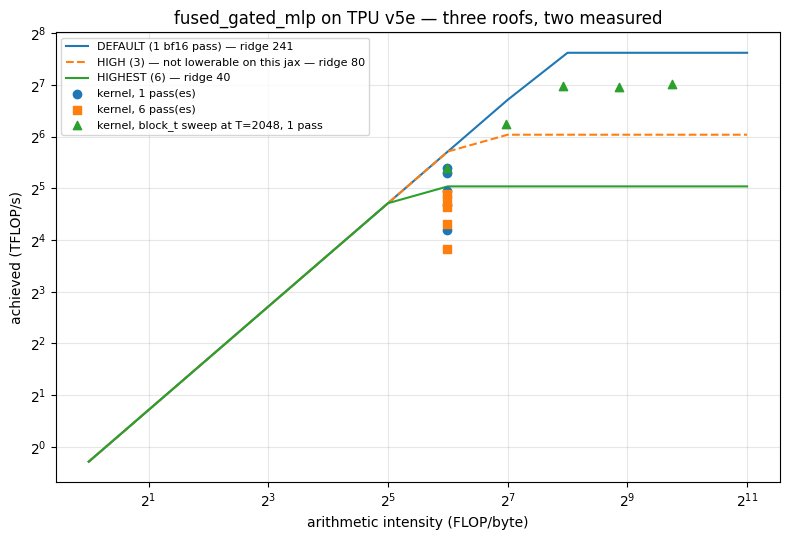

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))

intensities = [2**i for i in range(0, 12)]

# All three roofs are drawn, but the 3-pass one is dashed and labelled as
# untested: nothing measured here ran at HIGH, and a solid line would invite the
# eye to read points against a roof no point belongs to.
ROOFS = (
    (1, "DEFAULT (1 bf16 pass)", "-"),
    (3, "HIGH (3) — not lowerable on this jax", "--"),
    (6, "HIGHEST (6)", "-"),
)
for passes, name, style in ROOFS:
    peak = V5E.peak_flops(passes)
    roof = [min(peak, i * V5E.peak_hbm_bandwidth) / 1e12 for i in intensities]
    ax.plot(intensities, roof, style, label=f"{name} — ridge {V5E.ridge_point(passes):.0f}")

for rows, passes, marker in ((default_rows, 1, "o"), (highest_rows, 6, "s")):
    xs, ys = [], []
    for r in rows:
        if r.status != "ok" or r.block_t is None:
            continue
        flops = mlp_flops(r.tokens)
        xs.append(arithmetic_intensity(flops, mlp_bytes(r.tokens, block_t=r.block_t)))
        ys.append(flops / r.median() / 1e12)
    if xs:
        ax.scatter(xs, ys, marker=marker, zorder=3, label=f"kernel, {passes} pass(es)")

# Section 5b's sweep, same T and precision, block_t varied. Without it the plot
# shows the kernel only at block_t=128, which is the lowest intensity and the
# worst time it has.
xs, ys = [], []
for r in block_t_results:
    if r.status != "ok" or r.block_t is None or not r.median():
        continue
    flops = mlp_flops(r.tokens)
    xs.append(arithmetic_intensity(flops, mlp_bytes(r.tokens, block_t=r.block_t)))
    ys.append(flops / r.median() / 1e12)
if xs:
    ax.scatter(xs, ys, marker="^", zorder=3,
               label=f"kernel, block_t sweep at T={SWEEP_SEQ_LEN}, 1 pass")

ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("arithmetic intensity (FLOP/byte)")
ax.set_ylabel("achieved (TFLOP/s)")
ax.set_title("fused_gated_mlp on TPU v5e — three roofs, two measured")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / "roofline.png", dpi=150)
plt.show()

## 8 · Package

`results/` and `traces/` live on the runtime's disk and go when it does, so this
cell bundles them into one zip and downloads it through the browser. Worth it for
the trace in particular: re-opening it locally with `tensorboard-plugin-profile`
is how the DMA count gets read.

The numbers reach the repo as prose in
[`docs/measurements/0001-fused-gated-mlp-on-v5e.md`](https://github.com/denis-mil/gemma3-tpu-pallas/blob/main/docs/measurements/0001-fused-gated-mlp-on-v5e.md);
the raw artifacts are gitignored.

In [12]:
import datetime
import shutil

stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
staging = pathlib.Path(f"/content/phase2_v5e-{stamp}")
shutil.rmtree(staging, ignore_errors=True)
shutil.copytree(RESULTS, staging / "results")
shutil.copytree(TRACES, staging / "traces")

archive = pathlib.Path(shutil.make_archive(str(staging), "zip", root_dir=staging))
shutil.rmtree(staging, ignore_errors=True)

print(archive, f"{archive.stat().st_size / 1e6:.1f} MB")
for path in sorted(RESULTS.rglob("*")):
    if path.is_file():
        print(f"  results/{path.relative_to(RESULTS)}  {path.stat().st_size / 1e3:.0f} kB")
trace_files = [path for path in TRACES.rglob("*") if path.is_file()]
print(f"  traces/  {len(trace_files)} file(s), "
      f"{sum(path.stat().st_size for path in trace_files) / 1e6:.1f} MB")

from google.colab import files

files.download(str(archive))

/content/phase2_v5e-20260809-195205.zip 0.1 MB
  results/block_t_sweep.json  5 kB
  results/correctness.json  1 kB
  results/roofline.png  88 kB
  results/token_sweep.json  17 kB
  results/vmem_sweep.json  23 kB
  traces/  2 file(s), 0.1 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>